**Goal:** quantify relationships in the penguins data -- scatter plots, Pearson's r,
the full correlation heatmap -- and then catch a real Simpson's paradox in the act.
Pairs with the concept note
[Relationships Between Variables: Correlation & Bivariate Analysis](l08_concept_bivariate_correlation.qmd).

> This page is the read-only view. To run the lab, open the notebook
> (`l08_lab_bivariate_correlation.ipynb`) -- in Colab via the badge on the concept page,
> or locally.

## Prerequisites & Setup

Same dataset as L07 -- **Palmer Penguins** (Gorman, Williams & Fraser 2014, *PLoS ONE*;
CC0 public domain), 344 penguins, you already know its columns and its missing values.
No random numbers in this lab, so there is nothing to seed.

In [1]:
# Setup: run this cell first (required for Colab -- it resets on open)
%pip install -q pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Palmer Penguins -- Gorman, Williams & Fraser (2014), PLoS ONE; CC0 public domain
LOCAL = "data/penguins.csv"
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
penguins = pd.read_csv(LOCAL if os.path.exists(LOCAL) else URL)
print(penguins.shape)

(344, 7)


<details><summary>Expected Output</summary>

~~~text
(344, 7)
~~~
</details>

## Step 1: One Relationship -- Scatter Plot + r

Flipper length vs body mass: plot it, then read it with the four words (direction,
form, strength, unusual points) *before* computing anything.

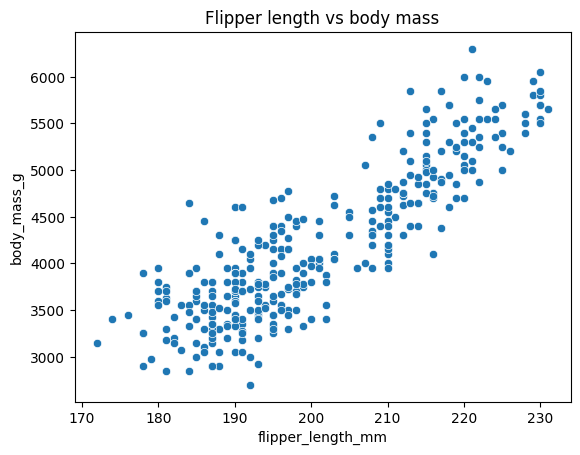

In [3]:
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g")
plt.title("Flipper length vs body mass")
plt.show()

**Read it:** direction positive (longer flippers, heavier birds), form roughly linear,
strength high -- the cloud is tight. No isolated stragglers. Now the number:

In [4]:
r = penguins["flipper_length_mm"].corr(penguins["body_mass_g"])
print(f"Pearson r = {r:+.2f}")

Pearson r = +0.87


<details><summary>Expected Output</summary>

~~~text
Pearson r = +0.87
~~~
*(Strong positive, matching the picture -- this is the well-behaved case where the
number and the plot agree. Note pandas quietly skipped the rows with missing values,
the ones you counted in L07.)*
</details>

The concept note warned that pooled data can hide groups. Cheap insurance: color the
same scatter by species.

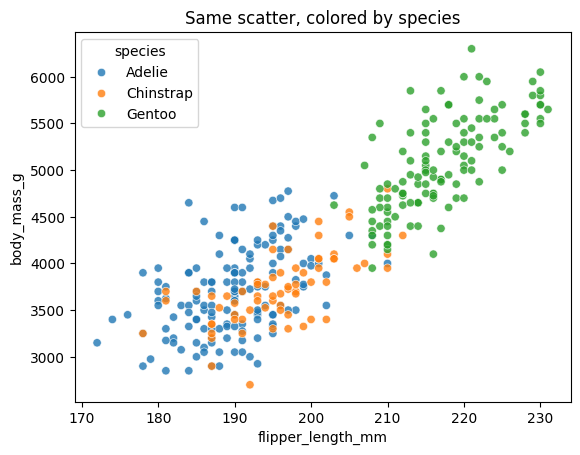

In [5]:
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g",
                hue="species", alpha=0.8)
plt.title("Same scatter, colored by species")
plt.show()

**Read it:** three clouds -- Gentoo sits clearly up-right (bigger on both axes), Adelie
and Chinstrap overlap lower-left. The overall positive trend survives the group view
here: it points the same way inside each cloud. Remember this check; in Step 3 it will
save us from a wrong conclusion.

## Step 2: All Relationships -- Matrix + Heatmap

Six pairs of measurements is already too many scatters to eyeball one by one. Compute
the full correlation matrix:

In [6]:
numeric = penguins.select_dtypes("number")
corr = numeric.corr()
corr.round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.24,0.66,0.60
bill_depth_mm,-0.24,1.00,-0.58,-0.47
flipper_length_mm,0.66,-0.58,1.00,0.87
body_mass_g,0.60,-0.47,0.87,1.00


<details><summary>Expected Output</summary>

~~~text
                   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
bill_length_mm               1.00          -0.24               0.66         0.60
bill_depth_mm               -0.24           1.00              -0.58        -0.47
flipper_length_mm            0.66          -0.58               1.00         0.87
body_mass_g                  0.60          -0.47               0.87         1.00
~~~
</details>

**Read it:** diagonal all 1.00 (every variable matches itself), and the matrix is
symmetric -- read one triangle. Step 1's +0.87 is here. The odd row is `bill_depth_mm`:
negative against *everything*, including **-0.47** with body mass.

A heatmap makes the matrix scannable. **Uncomment and fill the two ____ blanks**: the
first wants the matrix you just computed, the second wants the numbers drawn in the
cells (True/False).

In [7]:
# Uncomment and fill the two ____ blanks, then run:
# sns.heatmap(____, annot=____, cmap="coolwarm", vmin=-1, vmax=1)
# plt.title("Pearson correlation, penguin measurements")
# plt.show()

<details><summary>Expected Output</summary>

*(A 4 x 4 heatmap: deep red diagonal of 1.00, warm red 0.87 for flipper/body-mass,
and the bill-depth row/column in blues -- with -0.47 against body mass. Cool colors in
a measurements table where everything "should" grow together is the anomaly worth
chasing.)*
</details>

**Read it:** so deeper bills belong to *lighter* penguins? That is what the pooled
number claims. Time to check the claim the way Step 1 taught.

## Step 3: The Paradox -- Overall vs Within Species

Compute the bill-depth/body-mass correlation overall, then *within each species*:

In [8]:
pair = ["bill_depth_mm", "body_mass_g"]
print(f"overall    r = {penguins[pair[0]].corr(penguins[pair[1]]):+.2f}")
for species, group in penguins.groupby("species"):
    print(f"{species:10s} r = {group[pair[0]].corr(group[pair[1]]):+.2f}")

overall    r = -0.47
Adelie     r = +0.58
Chinstrap  r = +0.60
Gentoo     r = +0.72


<details><summary>Expected Output</summary>

~~~text
overall    r = -0.47
Adelie     r = +0.58
Chinstrap  r = +0.60
Gentoo     r = +0.72
~~~
*(The pooled correlation is moderately NEGATIVE; inside every single species it is
moderately-to-strongly POSITIVE. Both are computed correctly. They contradict each
other. This is Simpson's paradox, in the wild.)*
</details>

The scatter shows how the trick works:

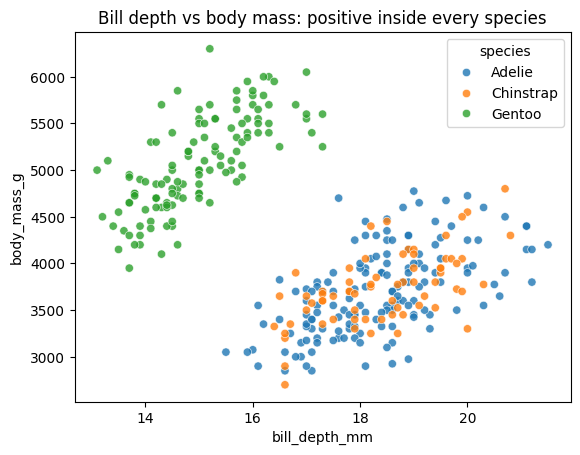

In [9]:
sns.scatterplot(data=penguins, x="bill_depth_mm", y="body_mass_g",
                hue="species", alpha=0.8)
plt.title("Bill depth vs body mass: positive inside every species")
plt.show()

**Read it:** three clouds, each tilting *upward* -- deeper bill, heavier bird, within
any one species. But Gentoo (heavy) happens to have shallow bills, so its cloud sits
high-left of the others; pool the species and the line through all three clouds tilts
*downward*. The lurking variable is species -- the same one that made L07's body-mass
histogram bimodal. Within-species is the honest answer here: report the pooled -0.47
and you have described penguin taxonomy, not penguin anatomy.

## Your Turn

### Exercise 1 -- Groups, Two Ways

Step 1's flipper/body-mass r was +0.87 pooled. Check it the honest way: draw a
**grouped box plot** of `body_mass_g` by `species` (one box per species), and compute
the **per-species r** for flipper vs body mass. Does the +0.87 survive the group
check, or is it another paradox? **Hint:** `sns.boxplot(data=penguins, x=..., y=...)`;
reuse Step 3's `groupby` loop with the other pair of columns.

In [10]:
# TODO: your code here (one grouped box plot, one groupby correlation loop)

<details><summary>Expected Output</summary>

~~~text
Adelie     r = +0.47
Chinstrap  r = +0.64
Gentoo     r = +0.70
~~~
*(The box plot shows Gentoo's whole distribution sitting about 1.3 kg above the
other two, which have nearly identical medians around 3700 g. The per-species r values
are all positive -- weaker than the pooled +0.87 (part of that number was just "Gentoo
is big"), but the direction survives. Not a paradox this time: the group check
*confirms* the pooled story instead of reversing it.)*
</details>

### Exercise 2 -- The Whole Dataset in One Figure

Draw the pair plot: every pairwise scatter plus each variable's distribution on the
diagonal, colored by species -- L07's histograms and this lab's scatters in one grid.
**Hint:** one line; `sns.pairplot(...)` with `hue=` (it drops the missing rows
itself). It takes a few seconds to draw. Then name one panel you would investigate
next, and why.

In [11]:
# TODO: your code here

<details><summary>Expected Output</summary>

*(A 4 x 4 grid: species-colored histograms on the diagonal -- the body-mass and
flipper bimodality from L07 now visibly explained by color -- and 12 scatter panels.
Any defensible pick works as the answer; the classic one is bill length vs bill depth,
where the three species form clearly separated clouds, which is exactly the kind of
structure Unit IV's classifiers will feed on.)*
</details>

### Exercise 3 -- Name the Confounder

**Task:** ice-cream sales correlate strongly with drowning deaths, month by month.
In two or three sentences: name the confounder, explain the mechanism, and give the
analogous statement for the bill-depth paradox of Step 3 (what plays the role of
"summer", and what would "banning ice cream" correspond to?).

<details><summary>One acceptable answer</summary>

The confounder is summer: hot weather independently raises both ice-cream sales and
swimming (hence drownings); neither causes the other. In Step 3 the role of summer is
played by species -- being a Gentoo independently makes a penguin heavier AND
shallower-billed, manufacturing the pooled negative correlation. "Banning ice cream to
prevent drownings" corresponds to filing down bills to fatten penguins: intervening on
a variable that never caused the outcome.
</details>

## Summary

- Scatter first, number second: direction / form / strength / unusual points, then
  Pearson's r (+0.87 for flipper vs body mass -- plot and number agreeing).
- `df.corr()` + heatmap scale the view to all pairs at once; anomalous cells (bill
  depth's blue row) are *leads to chase*, not conclusions.
- The chase paid off: bill depth vs body mass is r = -0.47 pooled but positive inside
  every species -- Simpson's paradox, caused by the same lurking species variable that
  made L07's histogram bimodal. Group-check every pooled correlation (`hue=` scatter or
  `groupby` r) before reporting it.
- Correlation is not causation: x->y, y->x, or a confounder moving both -- the data
  alone cannot pick, and Exercise 3's ice cream is the template for spotting the third.